# Gender Classification Using Machine Learning

## Project Overview

The objective of this project is to develop a machine learning model that can classify an individual's gender based on three physical attributes:

- Height (cm)
- Weight (kg)
- Age (years)

This project follows the complete machine learning workflow, including data preprocessing, exploratory data analysis (EDA), feature engineering, model training, evaluation, and prediction.

### Machine Learning Models Used
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- K-Nearest Neighbors (KNN)

### Goal
To identify the most effective classification algorithm for predicting gender from physical characteristics.

## Step 1: Import Required Libraries

In this step, we import all the necessary Python libraries required for data analysis, visualization, preprocessing, model training, and evaluation.

These libraries provide tools for:
- Data manipulation
- Data visualization
- Machine learning model development
- Model performance evaluation

In [141]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

## Step 2: Load the Dataset

The dataset is loaded into a Pandas DataFrame using the `read_csv()` function.

Loading the dataset is the first step in any data science project because it allows us to access and analyze the data that will be used for model development.

The `head()` function is used to view the first five rows of the dataset.

In [142]:
# Dataset from Kaggle: <https://www.kaggle.com/datasets/samehraouf/gender-classification-dataset>
data = pd.read_csv("/content/Gender_Classification_Data.csv")
data.head()

,gender,height,weight,age
0,female,166.835558,64.238722,38
1,female,166.321934,67.165489,65
2,male,193.424782,89.342636,67
3,female,167.027904,67.637666,55
4,male,191.822253,93.985117,29


## Step 3: Display the Last Five Records

The `tail()` function is used to view the last five rows of the dataset.

This helps verify that the dataset has been loaded correctly and provides a quick overview of the records at the end of the dataset.

In [143]:
data.tail()

,gender,height,weight,age
9995,female,159.231550,64.338891,33
9996,female,166.681690,67.197533,30
9997,female,163.973116,74.565143,65
9998,female,168.363149,72.459247,24
9999,male,188.717624,99.363680,47


## Step 4: Examine Dataset Information

The `info()` function provides a concise summary of the dataset.

It displays:
- Number of records
- Column names
- Data types
- Missing values

Understanding the structure of the dataset is essential before performing further analysis.

In [144]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   gender  10000 non-null  object 
 1   height  10000 non-null  float64
 2   weight  10000 non-null  float64
 3   age     10000 non-null  int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 312.6+ KB


## Step 5: Determine Dataset Dimensions

The `shape` attribute returns the total number of rows and columns present in the dataset.

This helps us understand the size of the dataset and the amount of data available for model training.

In [145]:
data.shape

(10000, 4)

## Step 6: Generate Statistical Summary

The `describe()` method provides descriptive statistics for numerical features.

The summary includes:
- Mean
- Standard deviation
- Minimum value
- Maximum value
- Quartiles

These statistics help us understand the distribution of the data.

In [146]:
data.describe()

,height,weight,age
count,10000.000000,10000.000000,10000.000000
mean,177.492357,77.532014,43.446300
std,14.119292,11.689473,15.138112
min,144.481109,34.171822,18.000000
25%,164.998420,68.922954,30.000000
50%,176.358023,76.671571,43.000000
75%,190.092636,85.438872,57.000000
max,217.483664,120.290552,69.000000


## Step 7: Check for Missing Values

Missing values can negatively affect machine learning models.

This step identifies whether any feature contains null values that may require cleaning or imputation before model training.

In [147]:
data.isnull().sum()

,0
gender,0
height,0
weight,0
age,0


## Step 8: Check for Duplicate Records

Duplicate records may introduce bias and affect model performance.

This step identifies duplicate entries present in the dataset so that they can be removed if necessary.

In [148]:
data.duplicated().sum()

np.int64(0)

## Step 9: Analyze Gender Distribution

A bar chart is used to visualize the distribution of male and female records.

This helps determine whether the dataset is balanced or imbalanced, which can influence model performance.

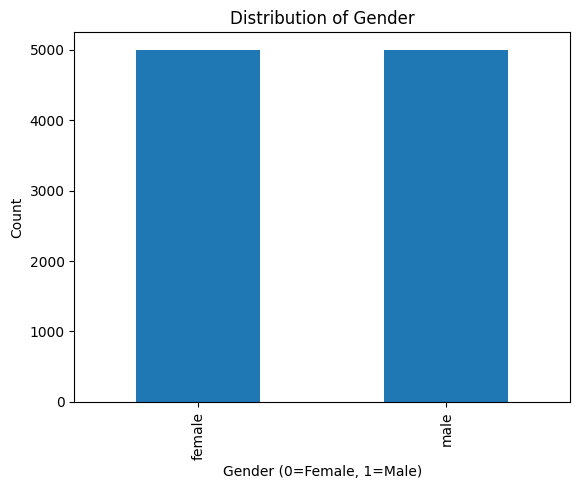

In [149]:
data['gender'].value_counts().plot(kind='bar')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.title('Distribution of Gender')
plt.show()

## Step 10: Visualize Height Distribution

A histogram is created to observe the distribution of height values.

This visualization helps identify:
- Data spread
- Central tendency
- Potential outliers

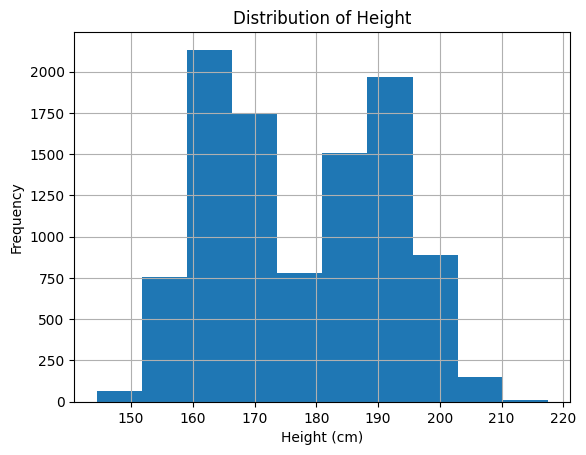

In [150]:
data['height'].hist()
plt.xlabel('Height (cm)')
plt.ylabel('Frequency')
plt.title('Distribution of Height')
plt.show()

## Step 11: Visualize Weight Distribution

This histogram illustrates how weight values are distributed across the dataset.

Understanding weight distribution helps identify patterns and unusual observations.

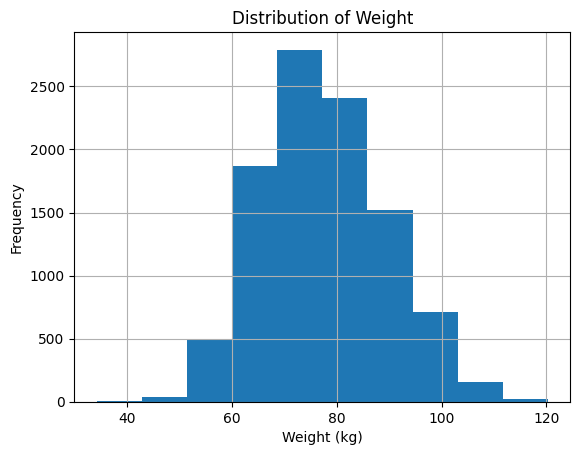

In [151]:
data['weight'].hist()
plt.xlabel('Weight (kg)')
plt.ylabel('Frequency')
plt.title('Distribution of Weight')
plt.show()

## Step 12: Visualize Age Distribution

A histogram is used to examine the age distribution of individuals in the dataset.

This helps determine whether age values are evenly distributed or concentrated within a specific range.

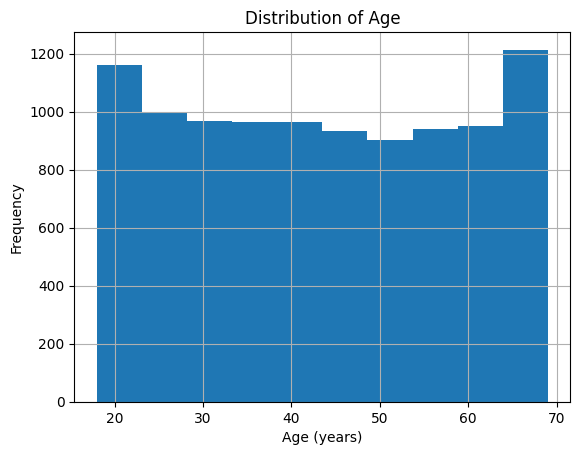

In [152]:
data['age'].hist()
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

## Step 13: Analyze Height by Gender

A box plot is used to compare height distributions between males and females.

This visualization helps determine whether height is a useful predictor for gender classification.

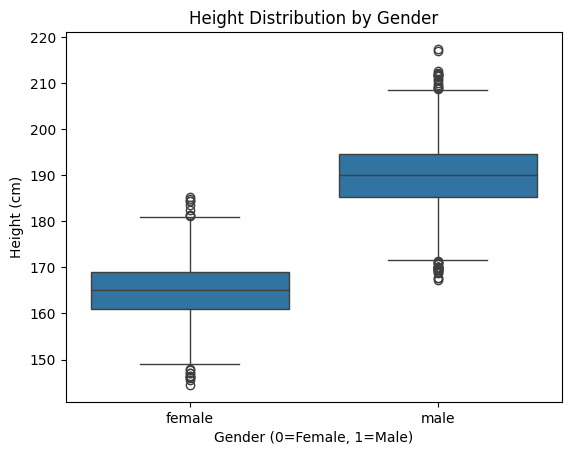

In [153]:
sns.boxplot(x='gender', y='height', data=data)
plt.xlabel('Gender')
plt.ylabel('Height (cm)')
plt.title('Height Distribution by Gender')
plt.show()

## Step 14: Analyze Weight by Gender

This box plot compares weight distributions across gender categories.

The objective is to identify whether weight significantly influences gender prediction.

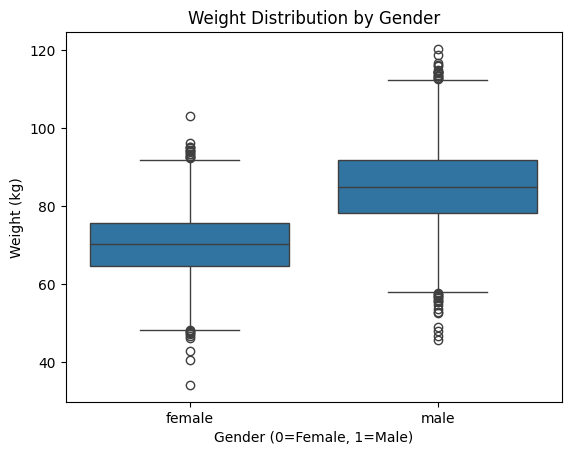

In [154]:
sns.boxplot(x='gender', y='weight', data=data)
plt.xlabel('Gender')
plt.ylabel('Weight (kg)')
plt.title('Weight Distribution by Gender')
plt.show()

## Step 15: Analyze Age by Gender

A box plot is used to compare age distributions between genders.

This helps evaluate whether age contributes meaningfully to classification performance.

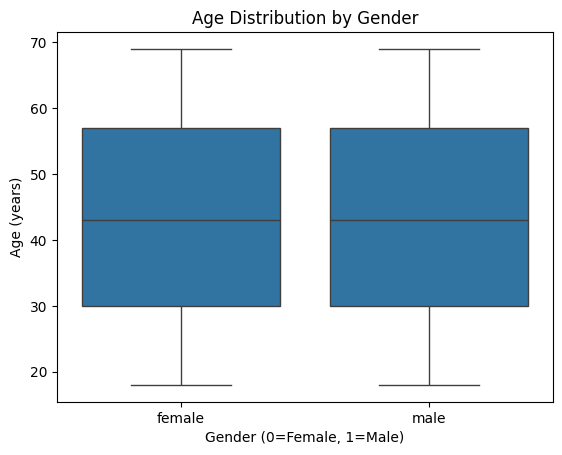

In [155]:
sns.boxplot(x='gender', y='age', data=data)
plt.xlabel('Gender')
plt.ylabel('Age (years)')
plt.title('Age Distribution by Gender')
plt.show()

## Step 16: Encode the Target Variable

Machine learning algorithms require numerical values rather than categorical labels.

Therefore, the gender column is converted into numerical form using Label Encoding.

Example:
- Female → 0
- Male → 1

In [156]:
le = LabelEncoder()
data['gender'] = le.fit_transform(data['gender'])

## Step 17: Correlation Analysis

A correlation matrix is generated to measure relationships among the features and the target variable.

The heatmap provides a visual representation of these relationships and helps identify the most influential features.

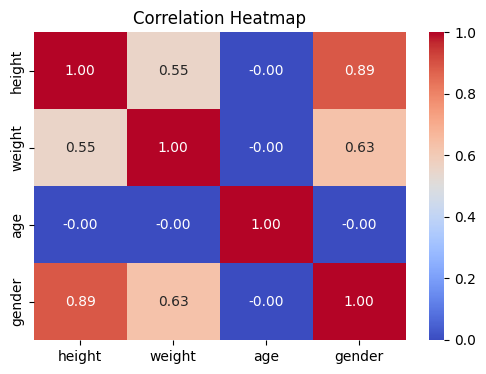

In [157]:
corr_matrix = data[['height', 'weight', 'age', 'gender']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Step 18: Define Features and Target Variable

The dataset is divided into:

### Features (X)
- Height
- Weight
- Age

### Target Variable (Y)
- Gender

This separation is necessary before training machine learning models.

In [158]:
X = data[['height', 'weight', 'age']]
Y = data['gender']

## Step 19: Split the Dataset

The dataset is divided into training and testing sets.

### Training Set
Used to train the machine learning models.

### Testing Set
Used to evaluate model performance on unseen data.

This ensures a fair assessment of model accuracy.

In [159]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

## Step 20: Standardize Feature Values

Feature scaling is performed using StandardScaler.

Standardization transforms features onto a common scale, which improves the performance of algorithms such as:
- Logistic Regression
- K-Nearest Neighbors

In [160]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 21: Train Logistic Regression Model

Logistic Regression is a statistical classification algorithm that predicts probabilities for binary outcomes.

In this step, the model learns the relationship between physical attributes and gender.

In [161]:
lr = LogisticRegression()
lr.fit(X_train_scaled, Y_train)
lr_prediction = lr.predict(X_test_scaled)

## Step 22: Train K-Nearest Neighbors (KNN) Classifier

KNN classifies new observations based on the majority class among their nearest neighboring data points.

This model relies on similarity between observations.

In [162]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, Y_train)
knn_prediction = knn.predict(X_test_scaled)

## Step 23: Train Decision Tree Classifier

Decision Trees classify data by learning a series of decision rules from the training dataset.

The model creates a tree-like structure to predict gender based on feature values.

In [163]:
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, Y_train)
dtc_prediction = dtc.predict(X_test)

## Step 24: Train Random Forest Classifier

Random Forest is an ensemble learning technique that combines multiple Decision Trees.

This approach generally improves prediction accuracy and reduces overfitting.

In [164]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, Y_train)
rfc_prediction = rfc.predict(X_test)

## Step 25: Evaluate Logistic Regression Model

The model's performance is assessed using:

- Accuracy Score
- Classification Report

These metrics help determine how well the model predicts gender.

In [165]:
print(accuracy_score(Y_test, lr_prediction))
print(classification_report(Y_test, lr_prediction))

0.987
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1000
           1       0.99      0.99      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



## Step 26: Evaluate K-Nearest Neighbors Model

The KNN model is evaluated using accuracy and classification metrics.

The results are compared against the other classification algorithms.

In [166]:
print(accuracy_score(Y_test, knn_prediction))
print(classification_report(Y_test, knn_prediction))

0.9855
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1000
           1       0.99      0.98      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



## Step 27: Evaluate Decision Tree Model

The Decision Tree model is evaluated using classification metrics.

The results will later be compared with other machine learning models.

In [167]:
print(accuracy_score(Y_test, dtc_prediction))
print(classification_report(Y_test, dtc_prediction))

0.9705
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1000
           1       0.97      0.97      0.97      1000

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000



## Step 28: Evaluate Random Forest Model

This step measures the predictive performance of the Random Forest classifier.

The evaluation helps determine whether ensemble learning improves classification accuracy.

In [168]:
print(accuracy_score(Y_test, rfc_prediction))
print(classification_report(Y_test, rfc_prediction))

0.9825
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1000
           1       0.98      0.98      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



## Step 29: Compare Model Performance

A comparison table is created to summarize the accuracy of all machine learning models.

The objective is to identify the best-performing model for gender classification.

In [169]:
comparison = pd.DataFrame({
    'Models': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(Y_test, lr_prediction),
        accuracy_score(Y_test, knn_prediction),
        accuracy_score(Y_test, dtc_prediction),
        accuracy_score(Y_test, rfc_prediction)
    ]
})
comparison = comparison.sort_values(by='Accuracy', ascending=False)
print(comparison)

                Models  Accuracy
0  Logistic Regression    0.9870
1                  KNN    0.9855
3        Random Forest    0.9825
2        Decision Tree    0.9705


## Step 30: Visualizing Model Comparison

To make the performance differences more intuitive, we visualize the accuracy scores of all models using a bar chart.

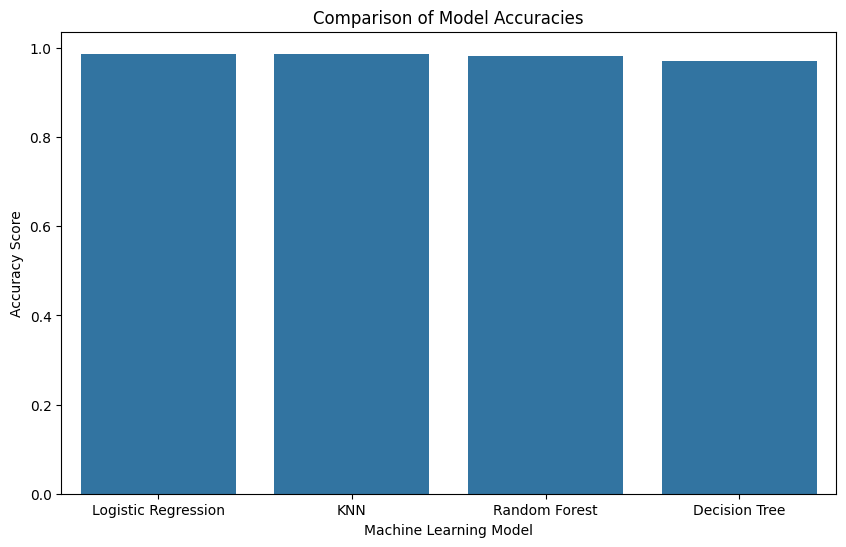

In [170]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Models', y='Accuracy', data=comparison)
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy Score')
plt.title('Comparison of Model Accuracies')
plt.show()

## Step 31: Analyze Feature Importance

Feature importance scores obtained from the Random Forest model indicate the contribution of each feature to the prediction process.

This analysis helps identify which physical characteristic has the greatest impact on gender classification.

In [171]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rfc.feature_importances_
})
importance = importance.sort_values(by='Importance', ascending=False)
print(importance)

  Feature  Importance
0  height    0.745325
1  weight    0.240737
2     age    0.013938


## Step 32: Gender Prediction Using Logistic Regression

A new sample record is provided to the trained Logistic Regression model.

The model predicts the gender based on the individual's height, weight, and age.

In [172]:
sample = pd.DataFrame({
    'height':[180], 'weight':[75], 'age':[25]
    })
sample = scaler.transform(sample)
prediction = lr.predict(sample)
print("Predicted Gender (Logistic Regression):", le.inverse_transform(prediction)[0])

Predicted Gender (Logistic Regression): male


## Step 33: Gender Prediction Using Decision Tree

The same sample observation is passed to the Decision Tree model.

The prediction demonstrates how the trained model can classify unseen data.

In [173]:
sample_raw = pd.DataFrame({'height':[180], 'weight':[75], 'age':[25]})
prediction = dtc.predict(sample_raw)
print("Predicted Gender (Decision Tree):", le.inverse_transform(prediction)[0])

Predicted Gender (Decision Tree): female


## Step 34: Gender Prediction Using Random Forest

The Random Forest model predicts the gender of a new individual using the learned patterns from the training data.

This demonstrates the practical application of the model.

In [174]:
sample_raw = pd.DataFrame({'height':[180], 'weight':[75], 'age':[25]})
prediction = rfc.predict(sample_raw)
print("Predicted Gender (Random Forest):", le.inverse_transform(prediction)[0])

Predicted Gender (Random Forest): male


## Step 35: Gender Prediction Using K-Nearest Neighbors

The KNN model predicts the gender of a new sample by comparing it with similar observations in the dataset.

This completes the prediction phase of the project.

In [175]:
sample = pd.DataFrame({
    'height':[180], 'weight':[75], 'age':[25]
    })
sample = scaler.transform(sample)
prediction = knn.predict(sample)
print("Predicted Gender (KNN):", le.inverse_transform(prediction)[0])

Predicted Gender (KNN): female


# Project Conclusion

In this project, machine learning techniques were applied to classify gender based on an individual's height, weight, and age.

The project followed a complete data science workflow:

1. Data Loading and Exploration
2. Data Quality Assessment
3. Exploratory Data Analysis (EDA)
4. Feature Encoding and Scaling
5. Model Development
6. Model Evaluation
7. Feature Importance Analysis
8. Prediction on New Data

Four classification algorithms were implemented and compared:

- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier
- K-Nearest Neighbors (KNN)

The results demonstrate how machine learning can identify patterns within physical attributes and use those patterns to predict gender effectively. The best-performing model can be selected based on the evaluation metrics and deployed for future predictions.